# IOR Read/Write – Per-Run Analysis

Combines all per-run CSV files in this directory into a single DataFrame,
extracts `n` (number of nodes) from the filename, counts config occurrences,
and computes the coefficient of variation (CV%) for read/write bandwidth.

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

## 1. Load and combine all CSVs

Filename convention: `ior_rw_n-{N}_ppn-{PPN}_tx-{TX}_{timestamp}.csv`

The `n`, `ppn`, and `tx` parameters are extracted from the filename and appended as columns.

In [2]:
data_dir = Path(".")  # notebook lives alongside the CSVs
csv_files = sorted(data_dir.glob("ior_rw_n-*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for f in csv_files:
    m = re.search(r'_n-(\d+)_ppn-(\d+)_tx-(\w+)_', f.stem)
    if not m:
        print(f"  skipping (no match): {f.name}")
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["n"]        = int(m.group(1))
    df["ppn"]      = int(m.group(2))
    df["tx"]       = m.group(3).upper()   # normalise: 2M, 16M
    df["filename"] = f.name
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["access"]   = combined["access"].str.strip().str.lower()
combined["bw_GiB_s"] = combined["bw(MiB/s)"] / 1024.0

print(f"Total rows : {len(combined)}")
combined.head()

Found 56 CSV files
Total rows : 1074


,access,bw(MiB/s),IOPS,Latency,block(KiB),xfer(KiB),open(s),wr/rd(s),close(s),total(s),numTasks,iter,n,ppn,tx,filename,bw_GiB_s
0,write,1.634177e+06,102692.5264,0.0739,131072.0,16384.0,0.0066,0.6382,0.0502,0.6417,256,0,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782550380.csv,1595.875623
1,read,1.465864e+06,92029.1795,0.0844,131072.0,16384.0,0.0063,0.7121,0.0509,0.7153,256,0,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782550380.csv,1431.507366
2,write,1.627054e+06,102219.0292,0.0749,131072.0,16384.0,0.0064,0.6411,0.0532,0.6445,256,1,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782550380.csv,1588.920202
3,read,1.460064e+06,91665.9353,0.0843,131072.0,16384.0,0.0064,0.7149,0.0526,0.7182,256,1,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782550380.csv,1425.844025
4,write,1.630208e+06,102423.3726,0.0742,131072.0,16384.0,0.0065,0.6399,0.0511,0.6432,256,2,16,16,16M,ior_rw_n-16_ppn-16_tx-16M_1782550380.csv,1591.999870


In [3]:
out_path = data_dir / "ior_rw_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved combined CSV → {out_path.resolve()}")

Saved combined CSV → /Users/xmei/Documents/LDRD/pdsw26_daos-bench-res/results/aurora/ior/ior-rw/ior_rw_combined.csv


## 2. Config counts

Each row in a CSV = one iter. Count how many iters exist per `(n, ppn, tx, access)` config.

In [4]:
config_cols = ["n", "ppn", "tx"]

iter_counts = (
    combined.groupby(config_cols + ["access"])
    .size()
    .rename("num_iters")
    .reset_index()
    .sort_values(config_cols + ["access"])
    .reset_index(drop=True)
)

print("Configurations with less than 10 iterations")
iter_counts[iter_counts["num_iters"] < 10]

Configurations with less than 10 iterations


,n,ppn,tx,access,num_iters
104,64,32,16M,read,4
105,64,32,16M,write,4
106,64,32,2M,read,9
107,64,32,2M,write,9
108,64,48,16M,read,2
109,64,48,16M,write,2
110,64,48,2M,read,2
111,64,48,2M,write,2


## 3. CV% for Read / Write bandwidth

CV (coefficient of variation) = σ / μ × 100 %, computed **across all iters** (rows) per config.  
Each row in the CSV is one iter measurement.

In [5]:
def cv_pct(x):
    return x.std(ddof=1) / x.mean() * 100 if len(x) > 1 and x.mean() != 0 else np.nan

stats = (
    combined.groupby(config_cols + ["access"])["bw_GiB_s"]
    .agg(mean_GiB_s="mean", std_GiB_s="std", cv_pct=cv_pct, num_iters="count")
    .reset_index()
    .sort_values(config_cols + ["access"])
)

CV_THRESH = 10.0

def highlight_high_cv(row):
    color = "background-color: #ffe0e0" if pd.notna(row["cv_pct"]) and row["cv_pct"] > CV_THRESH else ""
    return [color] * len(row)

high_cv = stats[stats["cv_pct"] > CV_THRESH]

display(
    high_cv.style
    .apply(highlight_high_cv, axis=1)
    .format({"mean_GiB_s": "{:.3f}", "std_GiB_s": "{:.3f}", "cv_pct": "{:.2f}"}, na_rep="—")
    .set_caption(f"CV% > {CV_THRESH}% configs  (red = CV > {CV_THRESH}%)")
)

,n,ppn,tx,access,mean_GiB_s,std_GiB_s,cv_pct,num_iters
34,4,8,2M,read,49.040,5.426,11.06,10
105,64,32,16M,write,3931.690,552.837,14.06,4
111,64,48,2M,write,3863.029,494.251,12.79,2


## 4. Peak Read/Write BW

In [6]:
peak_rows = []
for n_val in [1, 2, 4, 8, 16, 32, 64]:
    for access_type in ["write", "read"]:
        sub = combined[(combined["n"] == n_val) & (combined["access"] == access_type)]
        idx = sub["bw_GiB_s"].idxmax()
        row = sub.loc[idx]
        peak_rows.append({
            "n":          n_val,
            "access":     access_type,
            "peak_BW_GiB_s": row["bw_GiB_s"],
            "ppn":        int(row["ppn"]),
            "tx":         row["tx"],
            "iter":       int(row["iter"]),
            "filename":   row["filename"],
        })

peak_df = pd.DataFrame(peak_rows)
display(
    peak_df.style
    .format({"peak_BW_GiB_s": "{:.3f}"})
    .set_caption("Peak BW per n × access (best single iter across all configs)")
    .hide(axis="index")
)

n,access,peak_BW_GiB_s,ppn,tx,iter,filename
1,write,169.817,48,16M,6,ior_rw_n-1_ppn-48_tx-16M_1782551162.csv
1,read,138.764,32,16M,6,ior_rw_n-1_ppn-32_tx-16M_1782551085.csv
2,write,328.949,48,16M,5,ior_rw_n-2_ppn-48_tx-16M_1782552044.csv
2,read,272.417,32,16M,0,ior_rw_n-2_ppn-32_tx-16M_1782551966.csv
4,write,620.186,48,16M,4,ior_rw_n-4_ppn-48_tx-16M_1782552287.csv
4,read,591.002,48,16M,0,ior_rw_n-4_ppn-48_tx-16M_1782552287.csv
8,write,1127.180,48,16M,4,ior_rw_n-8_ppn-48_tx-16M_1782551448.csv
8,read,1049.354,48,16M,3,ior_rw_n-8_ppn-48_tx-16M_1782551448.csv
16,write,1976.974,48,16M,6,ior_rw_n-16_ppn-48_tx-16M_1782550533.csv
16,read,1830.809,48,16M,2,ior_rw_n-16_ppn-48_tx-16M_1782550533.csv


## 5. Scaling charts: peak BW vs nodes / PPN

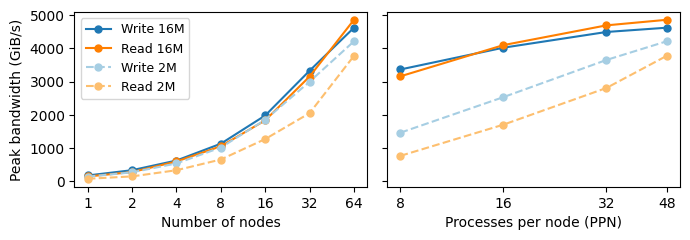

In [7]:
# Peak BW = max single-iter BW across all runs at each (n or ppn, tx, access) combo
peak = (
    combined.groupby(["n", "ppn", "tx", "access"])["bw_GiB_s"]
    .max()
    .reset_index()
    .rename(columns={"bw_GiB_s": "peak_GiB_s"})
)

# Styling helpers — Paired palette: light/dark pairs per hue
paired = mpl.colormaps["Paired"].colors
LINE_PROPS = {
    ("write", "16M"): {"color": paired[1], "linestyle": "-",  "alpha": 1.0},
    ("write", "2M"):  {"color": paired[0], "linestyle": "--", "alpha": 1.0},
    ("read",  "16M"): {"color": paired[7], "linestyle": "-",  "alpha": 1.0},
    ("read",  "2M"):  {"color": paired[6], "linestyle": "--", "alpha": 1.0},
}

MARKER = "o"
MS = 5

int_fmt = mpl.ticker.FuncFormatter(lambda x, _: f"{int(x)}")

def add_lines(ax, df, x_col):
    for tx in ["16M", "2M"]:
        for access in ["write", "read"]:
            sub = (
                df[(df["tx"] == tx) & (df["access"] == access)]
                .groupby(x_col)["peak_GiB_s"].max()
                .reset_index()
                .sort_values(x_col)
            )
            if sub.empty:
                continue
            props = LINE_PROPS[(access, tx)]
            ax.plot(
                sub[x_col], sub["peak_GiB_s"],
                color=props["color"],
                linestyle=props["linestyle"],
                alpha=props["alpha"],
                marker=MARKER,
                markersize=MS,
                label=f"{access.capitalize()} {tx}",
            )

fig, (ax_n, ax_ppn) = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True)

# ── (a) Peak BW vs number of nodes ─────────────────────────────────────────
add_lines(ax_n, peak, "n")
ax_n.set_xlabel("Number of nodes")
ax_n.set_ylabel("Peak bandwidth (GiB/s)")
ax_n.set_xscale("log", base=2)
n_ticks = sorted(peak["n"].unique().tolist())
ax_n.set_xticks(n_ticks)
ax_n.xaxis.set_major_formatter(int_fmt)
ax_n.xaxis.set_minor_locator(mpl.ticker.NullLocator())
ax_n.legend(frameon=True, fontsize=9)

# ── (b) Peak BW vs PPN ─────────────────────────────────────────────────────
add_lines(ax_ppn, peak, "ppn")
ax_ppn.set_xlabel("Processes per node (PPN)")
ax_ppn.set_xscale("log", base=2)
ppn_ticks = sorted(peak["ppn"].unique().tolist())
ax_ppn.set_xticks(ppn_ticks)
ax_ppn.xaxis.set_major_formatter(int_fmt)
ax_ppn.xaxis.set_minor_locator(mpl.ticker.NullLocator())

fig.tight_layout()
plt.savefig("ior-scaling.pdf", bbox_inches="tight")
plt.show()

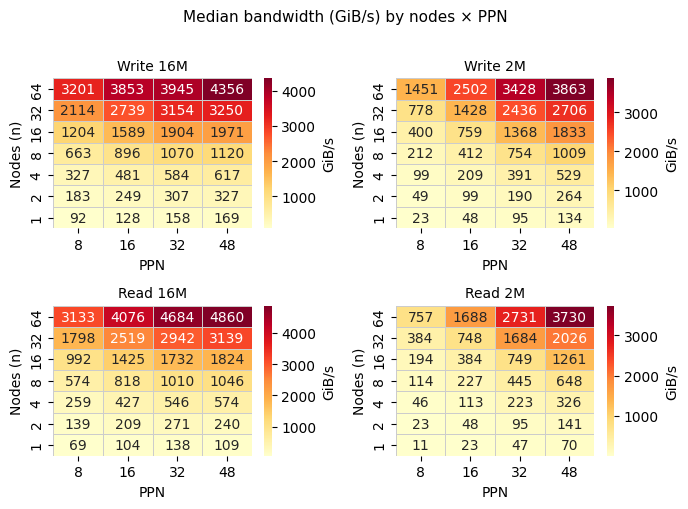

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

for col, tx_v in enumerate(["16M", "2M"]):
    for row, access_type in enumerate(["write", "read"]):
        ax = axes[row, col]
        sub = combined[(combined["access"] == access_type) & (combined["tx"] == tx_v)]
        pivot = (
            sub.groupby(["n", "ppn"])["bw_GiB_s"]
            .median()
            .unstack("ppn")
        )
        pivot = pivot.sort_index(ascending=False)  # largest n at top

        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt=".0f",
            cmap="YlOrRd",
            linewidths=0.4,
            linecolor="#cccccc",
            cbar_kws={"label": "GiB/s"},
        )
        ax.set_title(f"{access_type.capitalize()} {tx_v}", fontsize=10)
        ax.set_xlabel("PPN")
        ax.set_ylabel("Nodes (n)")

fig.suptitle("Median bandwidth (GiB/s) by nodes × PPN", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

In [9]:
# For peak-vs-n: which ppn gives the peak at each (n, tx, access)?
argmax_n = (
    peak.loc[peak.groupby(["n", "tx", "access"])["peak_GiB_s"].idxmax()]
    [["n", "ppn", "tx", "access", "peak_GiB_s"]]
    .sort_values(["access", "tx", "n"])
    .reset_index(drop=True)
    .rename(columns={"ppn": "best_ppn"})
)
print("Peak-vs-N: which ppn gives the peak at each (n, tx, access)?")
display(argmax_n)

# For peak-vs-ppn: which n gives the peak at each (ppn, tx, access)?
argmax_ppn = (
    peak.loc[peak.groupby(["ppn", "tx", "access"])["peak_GiB_s"].idxmax()]
    [["ppn", "n", "tx", "access", "peak_GiB_s"]]
    .sort_values(["access", "tx", "ppn"])
    .reset_index(drop=True)
    .rename(columns={"n": "best_n"})
)
print("\nPeak-vs-PPN: which n gives the peak at each (ppn, tx, access)?")
display(argmax_ppn)

Peak-vs-N: which ppn gives the peak at each (n, tx, access)?


,n,best_ppn,tx,access,peak_GiB_s
0,1,32,16M,read,138.763947
1,2,32,16M,read,272.416897
2,4,48,16M,read,591.001530
3,8,48,16M,read,1049.354476
4,16,48,16M,read,1830.808672
5,32,48,16M,read,3151.412237
6,64,48,16M,read,4860.488357
7,1,48,2M,read,70.224435
8,2,48,2M,read,141.830916
9,4,48,2M,read,327.974565



Peak-vs-PPN: which n gives the peak at each (ppn, tx, access)?


,ppn,best_n,tx,access,peak_GiB_s
0,8,64,16M,read,3158.276675
1,16,64,16M,read,4097.733155
2,32,64,16M,read,4692.932039
3,48,64,16M,read,4860.488357
4,8,64,2M,read,761.234101
5,16,64,2M,read,1701.117615
6,32,64,2M,read,2806.367527
7,48,64,2M,read,3773.826953
8,8,64,16M,write,3364.375881
9,16,64,16M,write,4020.286262


## 6. Raw BW scatter: all iters vs number of nodes

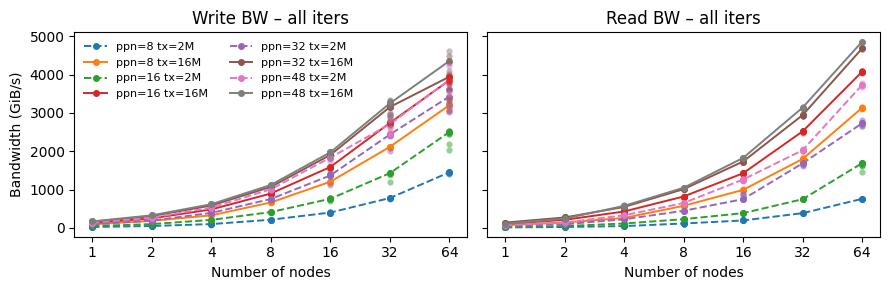

In [10]:
ppn_vals = sorted(combined["ppn"].unique())   # [8, 16, 32, 48]
tx_vals  = ["2M", "16M"]

cmap = mpl.colormaps["tab10"].colors
combo_colors = {}
for i, ppn_v in enumerate(ppn_vals):
    for j, tx_v in enumerate(tx_vals):
        combo_colors[(ppn_v, tx_v)] = cmap[i * len(tx_vals) + j]

linestyles = {"2M": "--", "16M": "-"}

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

for ax, access_type in zip(axes, ["write", "read"]):
    for ppn_v in ppn_vals:
        for tx_v in tx_vals:
            sub = combined[
                (combined["access"] == access_type) &
                (combined["ppn"] == ppn_v) &
                (combined["tx"] == tx_v)
            ]
            if sub.empty:
                continue
            color = combo_colors[(ppn_v, tx_v)]
            ax.scatter(
                sub["n"], sub["bw_GiB_s"],
                color=color, s=20, alpha=0.5, linewidths=0, zorder=3,
            )
            med = sub.groupby("n")["bw_GiB_s"].median().reset_index()
            ax.plot(
                med["n"], med["bw_GiB_s"],
                color=color, linestyle=linestyles[tx_v],
                linewidth=1.4, marker="o", markersize=4,
                label=f"ppn={ppn_v} tx={tx_v}",
            )
    ax.set_xlabel("Number of nodes")
    ax.set_title(f"{access_type.capitalize()} BW – all iters")
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(int_fmt)

axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].legend(frameon=False, fontsize=8, ncol=2)

fig.tight_layout()
plt.show()


## 7. PPN × N (total clients) analysis

Group all runs by total client count (`n × ppn`) and transfer size, collapsing the individual `n`/`ppn` split. This shows whether BW depends on the *total number of processes* regardless of how they are distributed across nodes.

,num_clients,tx,access,num_runs,max_GiB_s,median_GiB_s,std_GiB_s,cv_pct
0,8,16M,read,10,69.184,69.260,0.281,0.41
1,16,16M,read,20,121.290,120.378,18.306,15.09
2,32,16M,read,30,201.509,208.589,50.513,25.07
3,48,16M,read,10,108.381,108.686,1.710,1.58
4,64,16M,read,30,424.198,427.230,125.967,29.70
5,96,16M,read,10,239.501,239.800,7.089,2.96
6,128,16M,read,30,785.214,817.793,187.501,23.88
7,192,16M,read,10,570.671,573.880,15.717,2.75
8,256,16M,read,30,1411.341,1424.961,328.500,23.28
9,384,16M,read,10,1045.442,1045.939,2.355,0.23


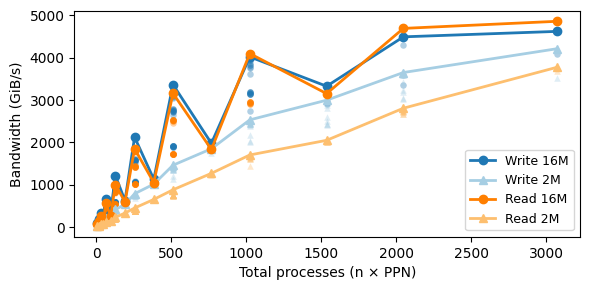

In [11]:
combined["num_clients"] = combined["n"] * combined["ppn"]

# ── Stats table ─────────────────────────────────────────────────────────────
client_stats = (
    combined.groupby(["num_clients", "tx", "access"])["bw_GiB_s"]
    .agg(
        num_runs="count",
        max_GiB_s="mean",
        median_GiB_s="median",
        std_GiB_s="std",
        cv_pct=cv_pct,
    )
    .reset_index()
    .sort_values(["access", "tx", "num_clients"])
    .reset_index(drop=True)
)

display(
    client_stats.style
    .format({
        "max_GiB_s":   "{:.3f}",
        "median_GiB_s": "{:.3f}",
        "std_GiB_s":    "{:.3f}",
        "cv_pct":       "{:.2f}",
    })
    .set_caption("BW stats grouped by total clients (n × ppn) × tx × access")
)

# ── Single figure: raw scatter + median line ─────────────────────────────────
SERIES = [
    ("write", "16M", paired[1],  "-",  "o",  "Write 16M"),
    ("write",  "2M", paired[0], "-",  "^",  "Write 2M"),
    ("read",  "16M", paired[7],  "-",  "o",  "Read 16M"),
    ("read",   "2M", paired[6], "-",  "^",  "Read 2M"),
]

fig, ax = plt.subplots(figsize=(6, 3))

for access_type, tx_v, color, ls, marker, label in SERIES:
    sub = combined[
        (combined["access"] == access_type) &
        (combined["tx"] == tx_v)
    ]
    if sub.empty:
        continue

    # Raw scatter
    ax.scatter(
        sub["num_clients"], sub["bw_GiB_s"],
        color=color, marker=marker, s=22, alpha=0.35, linewidths=0, zorder=3,
    )

    # Max line
    flag_line = sub.groupby("num_clients")["bw_GiB_s"].max().reset_index()
    ax.plot(
        flag_line["num_clients"], flag_line["bw_GiB_s"],
        color=color, linestyle=ls, linewidth=2,
        marker=marker, markersize=6,
        label=label, zorder=4,
    )

ax.set_xlabel("Total processes (n × PPN)")
ax.set_ylabel("Bandwidth (GiB/s)")
# ax.set_title("BW vs total clients – raw scatter + median")
ax.legend(frameon=True, fontsize=9, loc="lower right")
fig.tight_layout()
plt.savefig("ior-scaling-by-process.pdf", bbox_inches="tight")
plt.show()
